# Collect Data

# Prepare data
## Data preparation - step 1



In [1]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.functions import col
from pyspark.sql.functions import col, isnan
import seaborn as sns
import matplotlib.pyplot as plt


In the following, knowing that there is no header in the files and ";" is the seperator, we specified those options to import and merge the prices files from 2022 to 2024.

In [2]:
spark = (SparkSession.builder
         .appName("Prix")
         .config("spark.driver.memory", "8g")
         .config("spark.executor.memory", "8g")
         .config("spark.executor.cores", "2")
         .getOrCreate())

files_path = "../Data/1-raw/Prix*.csv.gz"

df_prices = (spark.read
    #.option("header", True)
    .option("inferSchema", True) 
    .option("sep", ";")              
    .csv(files_path)                 
)

df_prices.head(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/13 16:22:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 2, 7, 53, 26), _c6=1, _c7='Gazole', _c8=1.867),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 5, 9, 33, 37), _c6=1, _c7='Gazole', _c8=1.877),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 9, 14, 51, 49), _c6=1, _c7='Gazole', _c8=1.875),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 11, 9, 23, 54), _c6=1, _c7='Gazole', _c8=1.859),
 Row(_c0=1000001, _c1=1000, _c2='R', _c3=4620100.0, _c4=519800.0, _c5=datetime.datetime(2023, 1, 13, 9, 7, 40), _c6=1, _c7='Gazole', _c8=1.862)]

In the read.me, we saw the name of the columns and their descriptions. We just included them in order to rename our columns.

In [3]:
cols = [
    "id_pdv", "cp", "pop",
    "latitude", "longitude",
    "date",
    "id_carburant", "nom_carburant",
    "prix"
]

df_prices = df_prices.toDF(*cols)
df_prices.show(5)
df_prices.printSchema()

+-------+----+---+---------+---------+-------------------+------------+-------------+-----+
| id_pdv|  cp|pop| latitude|longitude|               date|id_carburant|nom_carburant| prix|
+-------+----+---+---------+---------+-------------------+------------+-------------+-----+
|1000001|1000|  R|4620100.0| 519800.0|2023-01-02 07:53:26|           1|       Gazole|1.867|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-05 09:33:37|           1|       Gazole|1.877|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-09 14:51:49|           1|       Gazole|1.875|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-11 09:23:54|           1|       Gazole|1.859|
|1000001|1000|  R|4620100.0| 519800.0|2023-01-13 09:07:40|           1|       Gazole|1.862|
+-------+----+---+---------+---------+-------------------+------------+-------------+-----+
only showing top 5 rows

root
 |-- id_pdv: integer (nullable = true)
 |-- cp: integer (nullable = true)
 |-- pop: string (nullable = true)
 |-- latitude: double (nullable =

Knowing the previous format of the files, we use the withColumn methods to extract the year, the month and the week of the year.

In [4]:
df_prices = (df_prices
    .withColumn("year",  F.year("date"))
    .withColumn("month", F.month("date"))
    .withColumn("week_of_year", F.weekofyear("date"))
)

df_prices.select("date","year","month","week_of_year").show(5)

+-------------------+----+-----+------------+
|               date|year|month|week_of_year|
+-------------------+----+-----+------------+
|2023-01-02 07:53:26|2023|    1|           1|
|2023-01-05 09:33:37|2023|    1|           1|
|2023-01-09 14:51:49|2023|    1|           2|
|2023-01-11 09:23:54|2023|    1|           2|
|2023-01-13 09:07:40|2023|    1|           2|
+-------------------+----+-----+------------+
only showing top 5 rows



In [5]:
# We divide the columns longitude and latitude by 10^5
# as it was making sense for the first one and keeping five zeros is common in order to get a 1-meter precision 
df_prices = (df_prices 
.withColumn("latitude", (F.col("latitude") / 100000)) 
.withColumn("longitude", (F.col("longitude") / 100000))
)

df_prices.select("latitude", "longitude").show(5)

+--------+---------+
|latitude|longitude|
+--------+---------+
|  46.201|    5.198|
|  46.201|    5.198|
|  46.201|    5.198|
|  46.201|    5.198|
|  46.201|    5.198|
+--------+---------+
only showing top 5 rows



In [6]:
# We try to identify all the rows with missing values
# As they are a few and they correspond to a small proportion, we will drop them all
condition = None
for c in df_prices.columns:
    if condition is None:
        condition = col(c).isNull() 
    else:
        condition = condition | col(c).isNull()

rows_with_na = df_prices.filter(condition)


count_rows_with_na = rows_with_na.count()
print(f"Numbers of rows with at least one NA: {count_rows_with_na}")
print(f"Proportion of rows with at least one NA: {count_rows_with_na / df_prices.count()}")


Numbers of rows with at least one NA: 12756


Proportion of rows with at least one NA: 0.000897372231563401


In [7]:
df_prices_filtered = df_prices.na.drop()

In [8]:
# In order to make the table available to spark SQL we use the the createOrReplaceTempView method
# We rename it prices_SQL
df_prices_filtered.createOrReplaceTempView('prices_SQL')
n_data = df_prices_filtered.count()

# We now will try to the distribution of each gas type in order to choose the two out of our interest
spark.sql(f""" 
SELECT nom_carburant, 
COUNT(*) * 1.0 / {n_data} AS freq 
FROM prices_SQL 
GROUP BY nom_carburant 
ORDER BY freq DESC 
"""
).show()


spark.sql(f"""
SELECT
  year,
  nom_carburant,
  COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY year) AS freq
FROM prices_SQL
GROUP BY year, nom_carburant
ORDER BY year, freq DESC
""").show()


+-------------+------------+
|nom_carburant|        freq|
+-------------+------------+
|       Gazole|0.2989266151|
|          E10|0.2506321433|
|         SP98|0.2412212689|
|          E85|0.0979138198|
|         SP95|0.0676675482|
|         GPLc|0.0436386048|
+-------------+------------+



+----+-------------+------------------+
|year|nom_carburant|              freq|
+----+-------------+------------------+
|2022|       Gazole|0.3071577117954053|
|2022|          E10|0.2471035455470010|
|2022|         SP98|0.2448219114743826|
|2022|          E85|0.0850825827424426|
|2022|         SP95|0.0749159165827607|
|2022|         GPLc|0.0409183318580078|
|2023|       Gazole|0.2985839418894967|
|2023|          E10|0.2512919696636149|
|2023|         SP98|0.2369624924706722|
|2023|          E85|0.1023582890292489|
|2023|         SP95|0.0671796467189213|
|2023|         GPLc|0.0436236602280460|
|2024|       Gazole|0.2904290313938861|
|2024|          E10|0.2537513517378210|
|2024|         SP98|0.2416986785938570|
|2024|          E85|0.1071685863650661|
|2024|         SP95|0.0603745346436153|
|2024|         GPLc|0.0465778172657545|
+----+-------------+------------------+



We notice by computing the proportion of each type of Gas by year and overall that the gas types SP95, GPLc and E85 are the least frequent with less than 10% each year so we decide to see their months frequencies in order to choose the two that we will delete.

In [9]:
spark.sql("""
SELECT
  year,
  month,
  nom_carburant,
  COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY year, month) AS freq
FROM prices_SQL
WHERE (nom_carburant IN ('SP95', 'GPLc', 'E85')) AND (year = 2023)
GROUP BY year, month, nom_carburant
ORDER BY year, month, freq DESC
""").show(50)


+----+-----+-------------+------------------+
|year|month|nom_carburant|              freq|
+----+-----+-------------+------------------+
|2023|    1|          E85|0.4587187621750988|
|2023|    1|         SP95|0.3409695552958201|
|2023|    1|         GPLc|0.2003116825290811|
|2023|    2|          E85|0.4859598015350440|
|2023|    2|         SP95|0.2940127964670045|
|2023|    2|         GPLc|0.2200274019979515|
|2023|    3|          E85|0.4796696081198837|
|2023|    3|         SP95|0.3196529167024632|
|2023|    3|         GPLc|0.2006774751776531|
|2023|    4|          E85|0.4934517113932187|
|2023|    4|         SP95|0.3101531951363222|
|2023|    4|         GPLc|0.1963950934704590|
|2023|    5|          E85|0.4860406572971879|
|2023|    5|         SP95|0.3085223463333797|
|2023|    5|         GPLc|0.2054369963694324|
|2023|    6|          E85|0.4956783454236765|
|2023|    6|         SP95|0.2934995112414467|
|2023|    6|         GPLc|0.2108221433348768|
|2023|    7|          E85|0.479579

After checking the frequencies of those last three gas types per month and per year, we see that E85 is the most frequent so will be most informative in order to predict a gas price.

In [10]:
df_clean = df_prices_filtered.filter(
    ~F.col("nom_carburant").isin(["GPLc", "SP95"])
)

df_clean.show(5)

+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+
| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant|nom_carburant| prix|year|month|week_of_year|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:26|           1|       Gazole|1.867|2023|    1|           1|
|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|       Gazole|1.877|2023|    1|           1|
|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|       Gazole|1.875|2023|    1|           2|
|1000001|1000|  R|  46.201|    5.198|2023-01-11 09:23:54|           1|       Gazole|1.859|2023|    1|           2|
|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|       Gazole|1.862|2023|    1|           2|
+-------+----+---+--------+---------+-------------------+------------+----------

## Data Preparation - step 2
We see in the following cell that for each station we have **one price per gas type per day**. For each gas type, we will average among every station for each day.

In [11]:
df_clean= (df_clean
    .withColumn("day",  F.to_date("date"))
)

df_clean.show(5)

df_clean.where(
    (F.col("day") == "2023-01-02") &
    (F.col("id_pdv") == 1000001)
).show()


+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant|nom_carburant| prix|year|month|week_of_year|       day|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:26|           1|       Gazole|1.867|2023|    1|           1|2023-01-02|
|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|       Gazole|1.877|2023|    1|           1|2023-01-05|
|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|       Gazole|1.875|2023|    1|           2|2023-01-09|
|1000001|1000|  R|  46.201|    5.198|2023-01-11 09:23:54|           1|       Gazole|1.859|2023|    1|           2|2023-01-11|
|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|       Gazole|1.862|2023|    1|           2|2023

+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant|nom_carburant| prix|year|month|week_of_year|       day|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:26|           1|       Gazole|1.867|2023|    1|           1|2023-01-02|
|1000001|1000|  R|  46.201|    5.198|2023-01-02 07:53:27|           6|         SP98|1.679|2023|    1|           1|2023-01-02|
+-------+----+---+--------+---------+-------------------+------------+-------------+-----+----+-----+------------+----------+



In [12]:
df_avg_price = (df_clean
    .groupBy("day", "nom_carburant")            
    .agg(F.avg("prix").alias("avg_day_price"))
)

df_clean_join = (df_clean
         .join(df_avg_price, on=["day", "nom_carburant"], how="left")
)

df_clean_join = (df_clean_join
    .withColumn("price_index", 100 * (((F.col("prix") - F.col("avg_day_price")) / F.col("avg_day_price")) + 1))
)

df_clean_join.where(df_clean_join.price_index > 100).show(5)

+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+------------------+
|       day|nom_carburant| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|       price_index|
+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+------------------+
|2023-07-04|         SP98|1000012|1000|  R|  46.201|      5.2|2023-07-04 00:01:00|           6| 1.99|2023|    7|          27|1.9090355969331778|104.24111541958095|
|2023-07-20|         SP98|1000012|1000|  R|  46.201|      5.2|2023-07-20 00:01:00|           6| 1.99|2023|    7|          29|1.9405723767382845|102.54706414737251|
|2023-07-04|         SP98|1100007|1100|  R|   46.25|    5.641|2023-07-04 00:01:00|           6|1.987|2023|    7|          27|1.9090355969331778|104.08396800940068|
|2023-07-20|    

In [13]:
df_clean_join = (df_clean_join
    .withColumn("week", 52 * (F.col("year") - 2022)  + F.col("week_of_year"))
)
df_clean_join.where(df_clean_join.year == 2023).show(5)

+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+
|       day|nom_carburant| id_pdv|  cp|pop|latitude|longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|
+----------+-------------+-------+----+---+--------+---------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+
|2023-01-13|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-13 09:07:40|           1|1.862|2023|    1|           2|1.9139778611632376|97.28430186064705|  54|
|2023-01-05|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-05 09:33:37|           1|1.877|2023|    1|           1|1.9289392361111177|97.30736794924493|  53|
|2023-01-09|       Gazole|1000001|1000|  R|  46.201|    5.198|2023-01-09 14:51:49|           1|1.875|2023|    1|           2|1.9082695153974822|98.2565609768936

# Visualize gas prices

In order to visualize the weekly prices of gas each type of gas, we will create a table first that will store it for each type of gas.

In [14]:
df_avg_price_week = (df_clean_join
    .groupBy("week", "nom_carburant")            
    .agg(F.avg("prix").alias("avg_week_price"))
    .orderBy("week", "nom_carburant"
))
df_avg_price_week.show(5)

+----+-------------+------------------+
|week|nom_carburant|    avg_week_price|
+----+-------------+------------------+
|   1|          E10| 1.672379523847547|
|   1|          E85|0.7532327197366702|
|   1|       Gazole|1.6024942140468652|
|   1|         SP98|1.7636169378785769|
|   2|          E10| 1.697089259085694|
+----+-------------+------------------+
only showing top 5 rows



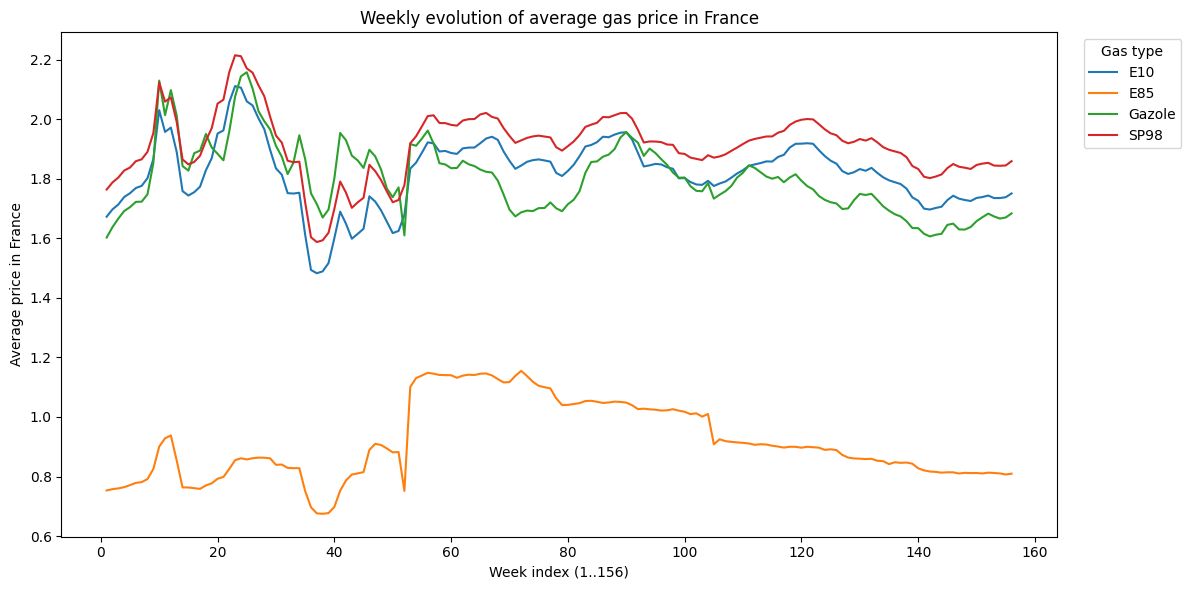

In [16]:
pd_avg_price_week = (df_avg_price_week
                        .toPandas())

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pd_avg_price_week,
    x="week",
    y="avg_week_price",
    hue="nom_carburant",
)
plt.xlabel("Week index (1..156)")
plt.ylabel("Average price in France")
plt.title("Weekly evolution of average gas price in France")
plt.legend(title="Gas type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Model gas prices evolution


We observe that our dataset contains **more than 10,000 distinct stations**.  
Using one-hot encoding on the station identifier would therefore introduce more than 10,000 dummy variables, which would lead to the **curse of dimensionality** and strongly degrade model performance.

To avoid this issue, we choose to model gas prices at a more aggregated geographical level: the **department**.

Let:

- $cp$  be the postal code of a station.  
- The department is defined as:

$
\text{department} = \left\lfloor \frac{cp}{1000} \right\rfloor
$

---


For the gas type, we choose SP98 arbitrarily. We model the daily price as a function of past prices and the department:

$
P_{t}^{(g)} = f \left(
P_{t-1}^{(g)},\;
P_{t-4}^{(g)},\;
P_{t-7}^{(g)},\;
\left\lfloor \frac{cp}{1000} \right\rfloor
\right)
$

Where:

- $ P_{t}^{(g)}$ is the price of gas type $g$ at day $$  
- $ P_{t-1}^{(g)}$ is the price one day before (lag-1)  
- $ P_{t-4}^{(g)}$ is the price four days before (lag-4)  
- $ P_{t-7}^{(g)}$ is the price seven days before (lag-7)  
- $ \left\lfloor \frac{cp}{1000} \right\rfloor$ is the department identifier  

---


In [17]:
data_model = df_clean_join.where(df_clean_join.nom_carburant == 'SP98')

In [18]:
from pyspark.sql.window import Window


window = Window.partitionBy("id_pdv").orderBy("date")

data_model = data_model.withColumn("price_1day_before", F.lag("prix", 1).over(window)) \
              .withColumn("price_4days_before", F.lag("prix", 4).over(window)) \
              .withColumn("price_7days_before", F.lag("prix", 7).over(window))

data_model.show(10)

+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+-----------------+------------------+------------------+
|       day|nom_carburant| id_pdv|  cp|pop|     latitude|         longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|price_1day_before|price_4days_before|price_7days_before|
+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+-----------------+------------------+------------------+
|2022-01-01|         SP98|1160005|1160|  R|46.0533506156|5.3374103671699995|2022-01-01 00:01:00|           6|1.736|2022|    1|          52|1.7814656084656062|97.44785370823037|  52|             NULL|              NULL|              NULL|
|2022-01-02|         SP98|1160005|1160|  R|46.05

In [19]:
# We delete the NA lines we have 7 at most
data_model = data_model.where(F.col("price_7days_before").isNotNull())
data_model.show(10)

+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+-----------------+------------------+------------------+
|       day|nom_carburant| id_pdv|  cp|pop|     latitude|         longitude|               date|id_carburant| prix|year|month|week_of_year|     avg_day_price|      price_index|week|price_1day_before|price_4days_before|price_7days_before|
+----------+-------------+-------+----+---+-------------+------------------+-------------------+------------+-----+----+-----+------------+------------------+-----------------+----+-----------------+------------------+------------------+
|2022-01-08|         SP98|1160005|1160|  R|46.0533506156|5.3374103671699995|2022-01-08 00:01:00|           6|1.747|2022|    1|           1|1.7834271141822935|97.95746549479846|   1|            1.739|             1.738|             1.736|
|2022-01-09|         SP98|1160005|1160|  R|46.05

# Evaluate if electric cars development as an impact